# SLIK Credit Risk — Insight Analysis

**Risk Data Analysis Intern Technical Test — Bagian C (Insight via Jupyter Notebook)**

Notebook ini menganalisis **SLIK aggregated table** (587 pemohon, posisi aplikasi pinjaman
**November 2023**) yang dibangun dengan SQL BigQuery (`sql/02_slik_aggregated_table.sql`) dan
telah divalidasi silang dengan dua implementasi pembanding di Python (pandas & DuckDB), seluruh
587×25 sel identik.

## Ringkasan untuk pembaca yang tidak punya waktu

| Temuan | Angka | Rekomendasi |
|---|---|---|
| Kriteria whitelist yang berjalan masih meloloskan pemohon macet | **13** pemohon "Others" sudah kol 3–5 | Tambahkan satu syarat: kol maks 12 bulan ≤ 2 (**skenario S2**) |
| Biaya dari syarat tambahan itu kecil | basis 86,9% → **83,5%**, NPL aktif yang lolos 1,57% → **0%** | Jalankan S2; S3/S4 memotong basis lagi tanpa menambah proteksi |
| Yang membedakan pemohon buruk adalah **jumlah** fasilitas, bukan besarnya | segmen NPL rata-rata **64 fasilitas** vs 18 di segmen bersih | Jadikan jumlah fasilitas & jejak keterlambatan inti scorecard |
| Eksposur besar justru lebih aman | bad rate desil 1 **20,3%** → desil 10 **8,5%** | Pakai eksposur untuk *sizing* limit, bukan untuk menolak |
| Kualitas portofolio memburuk selama jendela pengamatan | NPL 9,7% → **11,7%**, rata-rata DPD 27 → **52 hari** | Justifikasi kuat untuk pengetatan kriteria sekarang |

## Mengapa notebook, bukan hanya SQL dan dashboard?

1. **Narasi + kode + output dalam satu artefak** — reviewer bisa membaca alur berpikir sekaligus memverifikasi angkanya.
2. **Reproducible** — dijalankan ulang dari atas ke bawah menghasilkan angka yang sama; audit data quality terdokumentasi.
3. **Iterasi cepat untuk simulasi kebijakan** — cut-off whitelist diubah, dampaknya langsung terukur.
4. **Statistik yang tidak praktis di SQL/Looker** — chi-square, Information Value, Gini/AUC, selang kepercayaan Wilson.
5. **Terintegrasi dengan BigQuery** — di Google Colab tabel bisa ditarik langsung dengan magic `%%bigquery`.

## Agenda

1. Audit kualitas data
2. **Dua definisi "bad": mana yang boleh dipakai sebagai target** ← fondasi metodologis
3. Matrix report: `whitelist_flag` × kolektibilitas maks 6 bulan
4. Segmentasi pemohon berdasarkan perilaku SLIK
5. Uji kelayakan variabel scorecard (rank-ordering + IV/Gini/AUC)
6. Tren kualitas portofolio 24 bulan
7. Karakteristik demografis
8. Simulasi kebijakan whitelist
9. Kesimpulan & rekomendasi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

# ---------------- Design system Bank Jago ----------------
# 3 warna utama + 1 netral untuk pembanding + 1 warna sorot untuk data kunci.
AMBER, AMBER_SOFT   = "#FDAF27", "#FFF1D0"   # warna utama Jago
PURPLE, PURPLE_SOFT = "#722B79", "#EFE3F0"   # warna utama kedua = warna SOROT
SLATE               = "#8B9299"              # netral: data pembanding
INK, MUTED          = "#111111", "#6E7781"   # teks
GRID                = "#E4E7EA"

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 9, "text.color": INK, "axes.labelcolor": MUTED,
    "axes.titleweight": "bold", "axes.titlesize": 10.5, "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.edgecolor": GRID,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "legend.frameon": False,
})
CMAP_AMBER  = LinearSegmentedColormap.from_list("jago_amber",  ["#FFFFFF", AMBER_SOFT, AMBER])
CMAP_PURPLE = LinearSegmentedColormap.from_list("jago_purple", ["#FFFFFF", PURPLE_SOFT, PURPLE])
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA, OUT = "../data/Technical Test Dataset - {}.csv", "../output/{}"
APP_YM = "2023-11"  # bulan aplikasi pinjaman

raw   = pd.read_csv(DATA.format("result"), dtype=str)          # mentah, untuk audit
agg   = pd.read_csv(OUT.format("slik_aggregated_table.csv"), dtype={"NIK": str})
cust  = pd.read_csv(OUT.format("slik_customer_analysis.csv"), dtype={"NIK": str})
trend = pd.read_csv(OUT.format("slik_monthly_trend.csv"))
# Angka referensi dari pipeline SQL/Excel — dipakai untuk cross-check di sel 5c & 8.
ref_power = pd.read_csv(OUT.format("scorecard_power.csv"))
ref_scen  = pd.read_csv(OUT.format("whitelist_scenarios.csv"))

N = len(cust)
print(f"raw fasilitas : {raw.shape[0]:,} baris x {raw.shape[1]} kolom")
print(f"agregat       : {agg.shape[0]:,} pemohon x {agg.shape[1]} kolom")
print(f"analisis      : {N:,} pemohon x {cust.shape[1]} kolom")

raw fasilitas : 14,660 baris x 104 kolom
agregat       : 587 pemohon x 25 kolom
analisis      : 587 pemohon x 46 kolom


## 1. Audit Kualitas Data

Sebelum analisis, notebook memudahkan kita mengaudit kualitas data mentah — sesuatu yang sulit
didokumentasikan bila hanya memakai SQL console. Empat isu ditemukan dan **sudah ditangani di
query**, bukan ditambal di lapisan analisis.

In [2]:
audit = {
    "Fasilitas duplikat (kreditId >1 snapshot)":
        int(raw.duplicated("kreditId").sum()),
    "Nilai '#VALUE!' pada kolom tanggal (Excel error)":
        int((raw.filter(like="tanggal") == "#VALUE!").sum().sum()),
    "Kartu kredit berstatus AKTIF":
        int(((raw["jenisKredit"] == "X-30") & (raw["kondisi"] == "0")).sum()),
    "Fasilitas tanpa agunan (unsecured)":
        int(raw["jenisAgunan"].isna().sum()),
}
ljk_map = pd.read_csv(DATA.format("ljk mapping"), dtype=str)
audit["Kode LJK dengan >1 nama di mapping (harus di-dedup)"] = \
    int(ljk_map.groupby("ljk").size().gt(1).sum())

pd.Series(audit, name="jumlah").to_frame()

,jumlah
Fasilitas duplikat (kreditId >1 snapshot),27
Nilai '#VALUE!' pada kolom tanggal (Excel error),3483
Kartu kredit berstatus AKTIF,0
Fasilitas tanpa agunan (unsecured),14298
Kode LJK dengan >1 nama di mapping (harus di-dedup),368


**Temuan & penanganan:**
- **27 fasilitas punya snapshot ganda** (sebagian dengan `tanggalUpdate = '#VALUE!'`) → di-dedup dengan
  `ROW_NUMBER()`, mengambil snapshot ter-update (tie-break: baki debet terbesar, konservatif).
- **2.331 sel tanggal berisi `#VALUE!`** → seluruh casting memakai `SAFE.PARSE_DATE`/`SAFE_CAST`.
- **Tidak ada satu pun kartu kredit aktif** → seluruh metrik CC-aktif bernilai 0. Spesifikasi tetap
  meminta kolomnya, jadi kolom dibuat dan fakta ini dicatat terbuka: `slik_installment` praktis =
  angsuran pinjaman aktif, `slik_exposure` = outstanding personal loan aktif. Formula tetap benar
  bila portofolio kartu kredit muncul di kemudian hari.
- **97,5% fasilitas unsecured** → wajar untuk portofolio consumer/fintech lending.
- **Mapping LJK tidak unik per kode** (entitas konvensional & unit usaha syariah) → di-dedup sebelum
  join agar fasilitas tidak terduplikasi.

## 2. Dua Definisi "Bad" — dan Mana yang Boleh Dipakai sebagai Target

Ini keputusan metodologis paling menentukan di seluruh analisis, jadi ditaruh di depan.

Dataset ini adalah **snapshot statis** per November 2023: tidak ada *outcome window* ke depan.
Karena itu "bad" harus dibaca dari data yang sama — dan di sini muncul jebakan **tautologi**:
kalau saya menyaring pemohon dengan syarat "kol 12 bulan ≤ 2" lalu mengukur keberhasilannya
dengan "pernah kol ≥ 3 dalam 12 bulan", hasilnya **selalu** 0% karena kedua sisi memakai kolom
yang sama. Angka itu tidak membuktikan apa pun.

Solusinya: pisahkan dua definisi, dan pakai yang tidak beririsan dengan filternya.

In [3]:
cand = pd.DataFrame([
    {
        "kolom": "ever_npl_12m",
        "definisi": "pernah kol >= 3 pada 12 bulan sebelum aplikasi",
        "bad": int(cust["ever_npl_12m"].sum()),
        "% basis": round(100 * cust["ever_npl_12m"].mean(), 2),
        "peran": "KONTROL - dipakai membentuk segmen & filter, jadi tautologis",
    },
    {
        "kolom": "npl_now_active",
        "definisi": "kol >= 3 pada fasilitas yang MASIH AKTIF per 2023-11",
        "bad": int(cust["npl_now_active"].sum()),
        "% basis": round(100 * cust["npl_now_active"].mean(), 2),
        "peran": "TARGET - status berjalan, independen dari filter 12 bulan",
    },
]).set_index("kolom")

# Bukti bahwa keduanya benar-benar beda: 62 pemohon 'pernah' bermasalah tetapi
# fasilitas aktifnya kini lancar (sudah pulih atau fasilitasnya sudah ditutup).
xt = pd.crosstab(cust["ever_npl_12m"], cust["npl_now_active"],
                 rownames=["pernah NPL 12 bln"], colnames=["NPL aktif sekarang"])
display(cand)
xt

,definisi,bad,% basis,peran
kolom,,,,
ever_npl_12m,pernah kol >= 3 pada 12 bulan sebelum aplikasi,82,13.97,"KONTROL - dipakai membentuk segmen & filter, j..."
npl_now_active,kol >= 3 pada fasilitas yang MASIH AKTIF per 2...,20,3.41,"TARGET - status berjalan, independen dari filt..."


NPL aktif sekarang,0,1
pernah NPL 12 bln,,
0,505,0
1,62,20


**Insight #0 — target yang dipakai:**
- **`npl_now_active` (20 pemohon, 3,41%)** menjadi target untuk menguji kriteria whitelist dan
  daya pisah variabel scorecard. Kolom ini dibaca dari `kondisi = '0'` (fasilitas aktif) pada
  snapshot November 2023, sehingga **tidak** ikut membentuk filter 12 bulan.
- **`ever_npl_12m` (82 pemohon, 13,97%)** tetap dipakai — tetapi hanya di tempat yang tidak
  sirkular, yaitu **demografi** (bagian 7). Usia, pendidikan, gender, dan status pernikahan tidak
  dipakai membentuk kolom ini, jadi tidak ada tautologi; bonusnya, 82 kejadian jauh lebih stabil
  untuk dipecah per kelompok daripada 20 kejadian.
- Tabel silang di atas menunjukkan keduanya bukan kolom kembar: mayoritas pemohon yang *pernah*
  bermasalah kini fasilitas aktifnya lancar — sinyal pemulihan yang akan hilang kalau kita hanya
  melihat satu definisi.
- **Batasan yang jujur:** validasi sebenarnya tetap membutuhkan *vintage analysis* atas performa
  pinjaman setelah November 2023, yang tidak ada di dataset statis ini.

## 3. Matrix Report — `whitelist_flag` × Kolektibilitas Maks 6 Bulan Terakhir

`whitelist_flag` adalah aturan prioritas: **1. punya write-off → 2. punya restrukturisasi →
3. lainnya**. Matrix ini menguji seberapa selaras flag tersebut dengan perilaku pembayaran aktual
(kolektibilitas maksimum pada 6 bulan sebelum aplikasi).

Dua panel dipakai karena menjawab dua pertanyaan berbeda: **jumlah** menunjukkan di mana massa
pemohon berada, **persen per baris** membuat grup kecil (16 pemohon restrukturisasi) bisa
dibandingkan dengan grup besar (510 pemohon Others) tanpa bias ukuran.

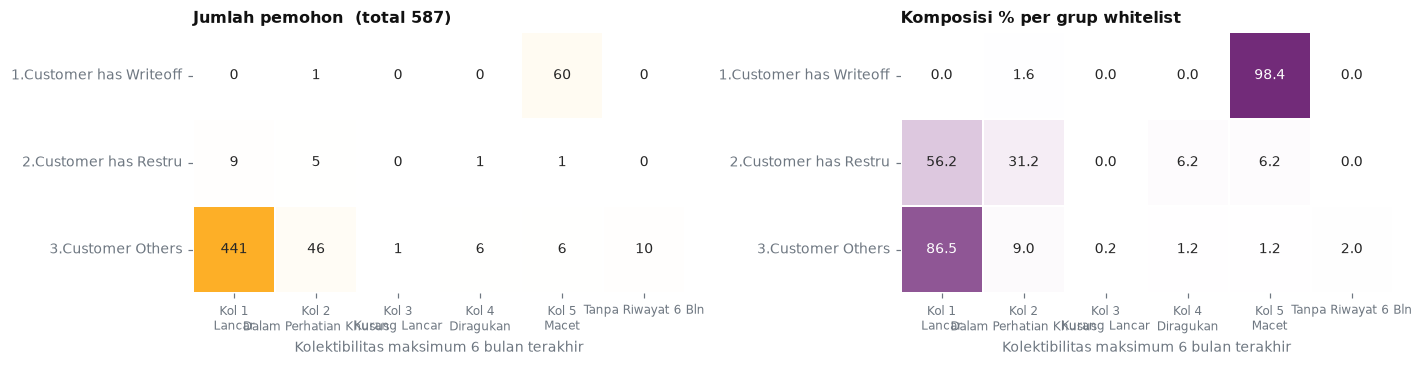

kol_6m_label,Kol 1 - Lancar,Kol 2 - Dalam Perhatian Khusus,Kol 3 - Kurang Lancar,Kol 4 - Diragukan,Kol 5 - Macet,Tanpa Riwayat 6 Bln,Total
whitelist_flag,,,,,,,
1.Customer has Writeoff,0,1,0,0,60,0,61
2.Customer has Restru,9,5,0,1,1,0,16
3.Customer Others,441,46,1,6,6,10,510


In [4]:
KOL_ORDER = ["Kol 1 - Lancar", "Kol 2 - Dalam Perhatian Khusus", "Kol 3 - Kurang Lancar",
             "Kol 4 - Diragukan", "Kol 5 - Macet", "Tanpa Riwayat 6 Bln"]
kol_order = [k for k in KOL_ORDER if k in set(cust["kol_6m_label"])]

mx = pd.crosstab(cust["whitelist_flag"], cust["kol_6m_label"]).reindex(columns=kol_order)
mx_pct = 100 * mx.div(mx.sum(axis=1), axis=0)
assert mx.to_numpy().sum() == N, "matrix harus mencakup seluruh 587 pemohon"

short = [c.replace(" - ", "\n") for c in mx.columns]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
sns.heatmap(mx, annot=True, fmt="d", cmap=CMAP_AMBER, ax=axes[0], cbar=False,
            linewidths=1, linecolor="white", annot_kws={"size": 9})
axes[0].set_title(f"Jumlah pemohon  (total {N})")
sns.heatmap(mx_pct, annot=True, fmt=".1f", cmap=CMAP_PURPLE, ax=axes[1], cbar=False,
            linewidths=1, linecolor="white", annot_kws={"size": 9})
axes[1].set_title("Komposisi % per grup whitelist")
for ax in axes:
    ax.set_xticklabels(short, fontsize=8, rotation=0)
    ax.set_xlabel("Kolektibilitas maksimum 6 bulan terakhir")
    ax.set_ylabel("")
    ax.grid(False)
plt.tight_layout(); plt.show()
mx.assign(Total=mx.sum(axis=1))

In [5]:
# Uji independensi: apakah whitelist_flag benar-benar terkait kolektibilitas?
tbl = pd.crosstab(cust["whitelist_flag"], cust["risk_band_6m"])
chi2, p, dof, _ = stats.chi2_contingency(tbl)
cramer_v = np.sqrt(chi2 / (N * (min(tbl.shape) - 1)))
print(f"Chi-square = {chi2:,.1f} | dof = {dof} | p-value = {p:.2e} -> "
      f"{'SIGNIFIKAN' if p < 0.05 else 'tidak signifikan'} pada alpha 5%")
print(f"Cramer's V = {cramer_v:.2f} (kekuatan asosiasi; >0,5 = sangat kuat)")

others = cust["whitelist_flag"] == "3.Customer Others"
leak_hist = others & (cust["kol_6m_label"].isin(
    ["Kol 3 - Kurang Lancar", "Kol 4 - Diragukan", "Kol 5 - Macet"]))
leak_now = others & (cust["npl_now_active"] == 1)
print(f"\nGrup 'Customer Others' : {int(others.sum())} pemohon")
print(f"  pernah kol 3-5 dalam 6 bulan terakhir : {int(leak_hist.sum())} "
      f"({100*leak_hist.sum()/others.sum():.1f}% dari grup)")
print(f"  MASIH NPL di fasilitas aktif sekarang : {int(leak_now.sum())} "
      f"({100*leak_now.sum()/others.sum():.1f}% dari grup)  <-- kebocoran nyata")

rehab = cust[(cust["whitelist_flag"] == "2.Customer has Restru")
             & (cust["kol_6m_label"] == "Kol 1 - Lancar")]
print(f"\nPemohon restrukturisasi yang kol-nya sudah lancar: {len(rehab)} dari "
      f"{int((cust['whitelist_flag'] == '2.Customer has Restru').sum())}")

Chi-square = 459.7 | dof = 6 | p-value = 4.10e-96 -> SIGNIFIKAN pada alpha 5%
Cramer's V = 0.63 (kekuatan asosiasi; >0,5 = sangat kuat)

Grup 'Customer Others' : 510 pemohon
  pernah kol 3-5 dalam 6 bulan terakhir : 13 (2.5% dari grup)
  MASIH NPL di fasilitas aktif sekarang : 8 (1.6% dari grup)  <-- kebocoran nyata

Pemohon restrukturisasi yang kol-nya sudah lancar: 9 dari 16


**Insight #1 — flag prioritas valid, tetapi belum kedap:**
- Hubungan `whitelist_flag` × kolektibilitas **sangat signifikan** (p ≪ 0,05) dengan asosiasi kuat:
  60 dari 61 pemohon write-off memang macet (kol 5) dalam 6 bulan terakhir. Flag menangkap sinyal
  yang benar — masalahnya bukan validitas, tapi cakupan.
- **13 pemohon "3.Customer Others" sudah kol 3–5** dalam 6 bulan terakhir, dan **8 di antaranya
  masih NPL pada fasilitas yang aktif hari ini**. Karena kriteria whitelist yang berjalan hanya
  mengandalkan write-off & restrukturisasi, kedelapan pemohon ini **lolos**.
- Sebaliknya, 9 dari 16 pemohon restrukturisasi justru sudah kol 1. Restrukturisasi yang berhasil
  layak diberi jalur rehabilitasi, bukan penolakan permanen.
- Implikasi: kriteria whitelist perlu satu syarat berbasis kolektibilitas — diuji di bagian 8.

## 4. Segmentasi Pemohon Berdasarkan Perilaku SLIK

Segmentasi rule-based, diurutkan dari sinyal terberat ke teringan: write-off → NPL/DPD > 90 →
restrukturisasi → menunggak ringan → bersih. Setiap pemohon masuk tepat satu segmen (segmen
pertama yang cocok), jadi jumlah segmen = 587.

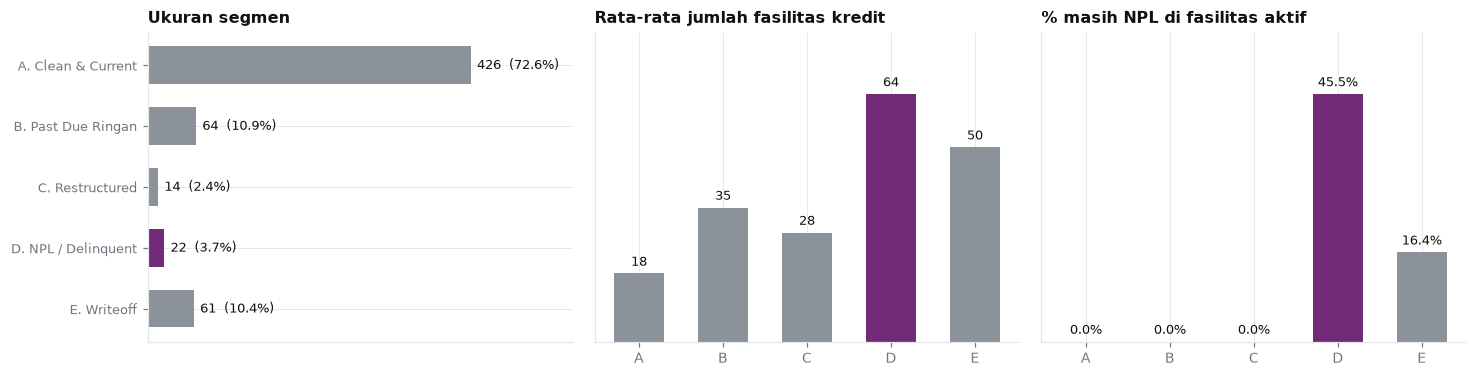

,pemohon,avg_fasilitas,avg_exposure,avg_mob,npl_aktif,pct
slik_behavior_segment,,,,,,
A. Clean & Current,426,17.70,"23,848,348.90",83.40,0.00,72.60
B. Past Due Ringan,64,34.80,"52,073,907.30",90.90,0.00,10.90
C. Restructured,14,28.30,"76,710,744.00",122.30,0.00,2.40
D. NPL / Delinquent,22,64.20,"30,000,058.40",79.60,45.50,3.70
E. Writeoff,61,50.40,"10,979,389.90",94.80,16.40,10.40


In [6]:
seg_order = ["A. Clean & Current", "B. Past Due Ringan", "C. Restructured",
             "D. NPL / Delinquent", "E. Writeoff"]
seg = (cust.groupby("slik_behavior_segment")
       .agg(pemohon=("NIK", "size"),
            avg_fasilitas=("flags_allcondition_count", "mean"),
            avg_exposure=("slik_exposure", "mean"),
            avg_mob=("mob_allcondition_max", "mean"),
            npl_aktif=("npl_now_active", "mean"))
       .reindex(seg_order))
seg["pct"] = 100 * seg["pemohon"] / seg["pemohon"].sum()
seg["npl_aktif"] *= 100

# Warna: netral untuk segmen yang tidak jadi inti argumen, SOROT untuk segmen D.
sorot = [PURPLE if s.startswith("D") else SLATE for s in seg.index]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.5))
b = axes[0].barh(seg.index[::-1], seg["pemohon"][::-1], color=sorot[::-1], height=.62)
axes[0].bar_label(b, labels=[f"{v:,.0f}  ({p:.1f}%)" for v, p in
                             zip(seg["pemohon"][::-1], seg["pct"][::-1])],
                  padding=4, fontsize=8.5, color=INK)
axes[0].set_title("Ukuran segmen"); axes[0].set_xlim(0, 560); axes[0].set_xticks([])
axes[0].tick_params(axis="y", labelsize=8.5)

for ax, col, judul, fmt in [
    (axes[1], "avg_fasilitas", "Rata-rata jumlah fasilitas kredit", "{:.0f}"),
    (axes[2], "npl_aktif", "% masih NPL di fasilitas aktif", "{:.1f}%"),
]:
    b = ax.bar([s[:1] for s in seg.index], seg[col], color=sorot, width=.6)
    ax.bar_label(b, labels=[fmt.format(v) for v in seg[col]], padding=3, fontsize=8.5)
    ax.set_title(judul); ax.set_ylim(0, seg[col].max() * 1.25); ax.set_yticks([])
plt.tight_layout(); plt.show()
seg.round(1)

**Insight #2 — "credit shopper" adalah sinyal bahaya, bukan besarnya pinjaman:**
- **72,6% basis pemohon bersih** (segmen A) — pool whitelist yang sehat dan besar.
- Segmen **D (NPL/Delinquent) rata-rata memegang 64 fasilitas kredit**, ±3,6× segmen A (18).
  Perilaku memburu kredit di banyak lembaga — terutama multifinance/fintech — berpasangan dengan
  kegagalan bayar. Ini menjadikan `flags_allcondition_count` kandidat variabel scorecard, dan
  daya pisahnya diuji secara formal di bagian 5.
- Segmen **C (Restructured) justru bereksposur terbesar** (rata-rata Rp 77 juta) dengan umur kredit
  terpanjang (122 bulan) — debitur lama bernilai besar yang sedang diselamatkan. Perlakukan sebagai
  *watchlist* dengan limit terbatas, bukan auto-reject permanen.
- Segmen E (Writeoff) tetap 16,4% NPL di fasilitas aktif: sebagian sudah pulih di fasilitas lain,
  tetapi risikonya masih jauh di atas basis (3,4%).

## 5. Uji Kelayakan Variabel Scorecard

Spesifikasi meminta evaluasi `slik_installment` dan `slik_exposure`. Saya menambahkan lima
kandidat lain dari tabel agregat supaya perbandingannya adil — sebuah variabel hanya bisa
disebut "layak" bila dibandingkan dengan alternatifnya.

Definisi (sesuai spesifikasi):
- `slik_installment` = 5% × outstanding kartu kredit aktif + angsuran bulanan pinjaman aktif
- `slik_exposure` = limit kartu kredit aktif + outstanding personal loan aktif

Tiga uji dipakai, dengan target **`npl_now_active`** (independen, lihat bagian 2):
1. **Bentuk distribusi** — apakah variabelnya bisa dibin dengan wajar?
2. **Rank-ordering per desil** — apakah risiko bergerak monoton?
3. **Information Value & Gini/AUC** — seberapa besar daya pisahnya, dan ke arah mana?

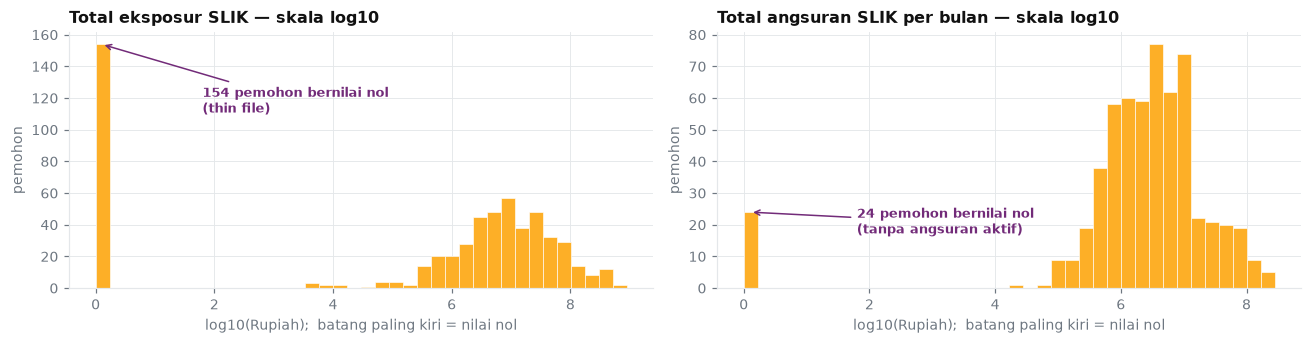

                  count          mean           std  min        25%          50%           75%            max
slik_exposure    587.00 27,079,763.00 73,827,194.00 0.00       0.00 3,578,866.00 19,133,245.00 888,338,421.00
slik_installment 587.00 12,501,294.00 29,607,023.00 0.00 882,767.00 3,139,010.00  9,235,174.00 281,308,502.00

Korelasi Spearman exposure vs installment: 0.41 -> hanya moderat, jadi keduanya membawa informasi yang tidak sepenuhnya sama
Pemohon thin file (slik_exposure = 0): 154 (26.2% basis) <- kelompok ini yang perlu diperhatikan


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
for ax, col, judul, ket in [
    (axes[0], "slik_exposure", "Total eksposur SLIK", "thin file"),
    (axes[1], "slik_installment", "Total angsuran SLIK per bulan", "tanpa angsuran aktif"),
]:
    nol = int((cust[col] == 0).sum())
    ax.hist(np.log10(cust[col].clip(lower=1)), bins=38, color=AMBER, edgecolor="white", lw=.4)
    ax.set_title(f"{judul} — skala log10")
    ax.set_xlabel("log10(Rupiah);  batang paling kiri = nilai nol")
    ax.set_ylabel("pemohon")
    ax.annotate(f"{nol} pemohon bernilai nol\n({ket})", xy=(0.1, nol), xytext=(1.8, nol * .72),
                fontsize=8.5, color=PURPLE, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=PURPLE, lw=1))
plt.tight_layout(); plt.show()

print(cust[["slik_exposure", "slik_installment"]].describe().T.round(0).to_string())
rho = cust[["slik_exposure", "slik_installment"]].corr(method="spearman").iloc[0, 1]
print(f"\nKorelasi Spearman exposure vs installment: {rho:.2f} -> hanya moderat, "
      f"jadi keduanya membawa informasi yang tidak sepenuhnya sama")
print(f"Pemohon thin file (slik_exposure = 0): {int(cust['is_thin_file'].sum())} "
      f"({100*cust['is_thin_file'].mean():.1f}% basis) <- kelompok ini yang perlu diperhatikan")

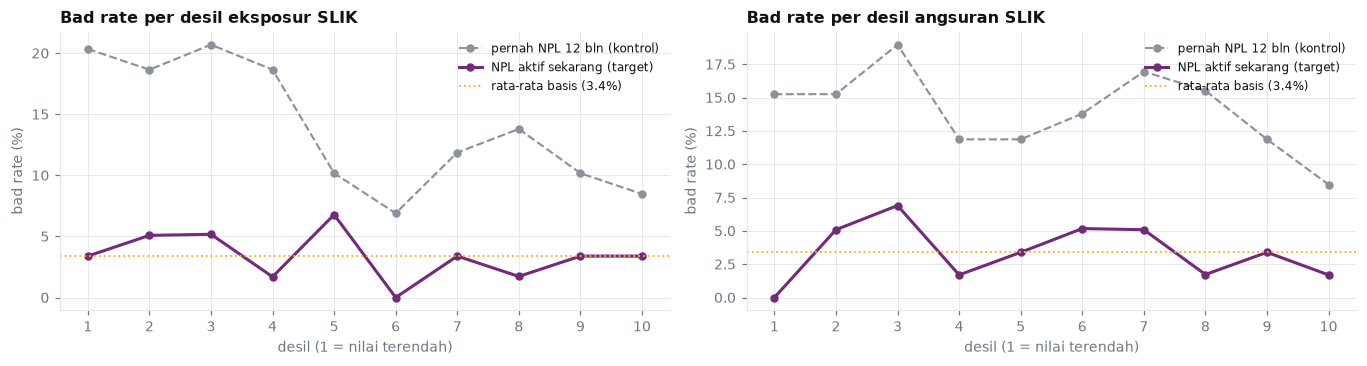

Desil eksposur terendah : 20.3% pernah NPL 12 bulan
Desil eksposur tertinggi: 8.5% pernah NPL 12 bulan


,n,bad,vmin,vmax,bad_rate
desil,,,,,
1,59,2,0.00,0.00,3.40
2,59,3,0.00,0.00,5.10
3,58,3,0.00,"282,250.20",5.20
4,59,1,"282,661.70","1,655,064.80",1.70
5,59,4,"1,698,853.90","3,578,865.50",6.80
6,58,0,"3,623,079.50","7,080,922.40",0.00
7,59,2,"7,122,441.50","13,130,649.00",3.40
8,58,1,"13,262,099.20","26,080,542.90",1.70
9,59,2,"26,414,429.00","67,429,784.90",3.40


In [8]:
TARGET = "npl_now_active"   # outcome independen (lihat bagian 2)

def deciles(metric, target=TARGET):
    d = cust[[metric, target]].copy()
    d["desil"] = pd.qcut(d[metric].rank(method="first"), 10, labels=range(1, 11))
    g = d.groupby("desil", observed=True).agg(n=(target, "size"), bad=(target, "sum"),
                                             vmin=(metric, "min"), vmax=(metric, "max"))
    g["bad_rate"] = 100 * g["bad"] / g["n"]
    return g

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.4))
for ax, col, judul in [(axes[0], "slik_exposure", "eksposur SLIK"),
                       (axes[1], "slik_installment", "angsuran SLIK")]:
    for tgt, warna, nama in [("ever_npl_12m", SLATE, "pernah NPL 12 bln (kontrol)"),
                             (TARGET, PURPLE, "NPL aktif sekarang (target)")]:
        g = deciles(col, tgt)
        ax.plot(g.index.astype(int), g["bad_rate"], marker="o", ms=4.5,
                color=warna, lw=2 if tgt == TARGET else 1.4,
                ls="-" if tgt == TARGET else "--", label=nama)
    ax.axhline(100 * cust[TARGET].mean(), color=AMBER, lw=1.2, ls=":",
               label=f"rata-rata basis ({100*cust[TARGET].mean():.1f}%)")
    ax.set_title(f"Bad rate per desil {judul}")
    ax.set_xlabel("desil (1 = nilai terendah)"); ax.set_ylabel("bad rate (%)")
    ax.set_xticks(range(1, 11)); ax.legend(fontsize=7.6, loc="upper right")
plt.tight_layout(); plt.show()

de = deciles("slik_exposure", "ever_npl_12m")
print(f"Desil eksposur terendah : {de['bad_rate'].iloc[0]:.1f}% pernah NPL 12 bulan")
print(f"Desil eksposur tertinggi: {de['bad_rate'].iloc[-1]:.1f}% pernah NPL 12 bulan")
deciles("slik_exposure").round(1)

In [9]:
# --- Information Value + Gini/AUC: rumus identik dengan pipeline SQL & Excel ---
def iv_gini(metric, target=TARGET, bins=10):
    """IV dan Gini (=|2*AUC-1|). AUC < 0,5 berarti arah hubungan TERBALIK."""
    d = cust[[metric, target]].dropna().copy()
    d["b"] = pd.qcut(d[metric].rank(method="first"), bins, labels=False)
    t = d.groupby("b").agg(n=(target, "size"), bad=(target, "sum"))
    t["good"] = t["n"] - t["bad"]
    tot_b, tot_g = t["bad"].sum(), t["good"].sum()
    p_b = (t["bad"] / tot_b).replace(0, 0.5 / tot_b)     # koreksi bin kosong
    p_g = (t["good"] / tot_g).replace(0, 0.5 / tot_g)
    iv = float(((p_b - p_g) * np.log(p_b / p_g)).sum())
    x, y = d[metric].values, d[target].values
    r = pd.Series(x).rank().values                        # average rank = Mann-Whitney U
    n1, n0 = y.sum(), (1 - y).sum()
    auc = (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)
    return iv, abs(2 * auc - 1), auc

KANDIDAT = [
    ("flags_active_dpd10plus_count", "Jumlah fasilitas aktif pernah telat >10 hari"),
    ("flags_allcondition_count", "Jumlah fasilitas kredit (semua kondisi)"),
    ("flags_restructured_allcondition_unsecured_count", "Jumlah fasilitas tanpa agunan direstrukturisasi"),
    ("slik_exposure", "Total eksposur SLIK (limit CC + outstanding KTA)"),
    ("balance_unsecured_sum", "Total outstanding tanpa agunan"),
    ("mob_allcondition_max", "Umur kredit terlama (bulan)"),
    ("slik_installment", "Total angsuran SLIK per bulan"),
]
rows = []
for m, label in KANDIDAT:
    iv, gini, auc = iv_gini(m)
    rows.append({"metric": m, "label": label, "iv": round(iv, 3), "gini": round(gini, 3),
                 "auc": round(auc, 3),
                 "arah": "Searah (naik = lebih berisiko)" if auc >= .5
                         else "Terbalik (naik = lebih aman)",
                 "kekuatan": ("Kuat" if gini >= .4 else "Sedang" if gini >= .2
                              else "Lemah" if gini >= .1 else "Tidak dapat dipakai")})
power = pd.DataFrame(rows).sort_values("gini", ascending=False).reset_index(drop=True)

# Cross-check: angka notebook harus sama persis dengan output pipeline SQL/Excel.
cek = power.merge(ref_power, on="metric", suffixes=("_nb", "_ref"))
beda = int((cek[["iv_nb", "gini_nb", "auc_nb"]].values
           != cek[["iv_ref", "gini_ref", "auc_ref"]].values).sum())
print(f"Cross-check vs output/scorecard_power.csv (BigQuery & Excel): {beda} sel berbeda "
      f"{'-> IDENTIK' if beda == 0 else '-> PERIKSA'}")
power.set_index("label")[["iv", "gini", "auc", "arah", "kekuatan"]]

Cross-check vs output/scorecard_power.csv (BigQuery & Excel): 0 sel berbeda -> IDENTIK


,iv,gini,auc,arah,kekuatan
label,,,,,
Jumlah fasilitas aktif pernah telat >10 hari,2.67,0.91,0.95,Searah (naik = lebih berisiko),Kuat
Jumlah fasilitas kredit (semua kondisi),0.73,0.28,0.64,Searah (naik = lebih berisiko),Sedang
Jumlah fasilitas tanpa agunan direstrukturisasi,0.60,0.12,0.56,Searah (naik = lebih berisiko),Lemah
Total eksposur SLIK (limit CC + outstanding KTA),0.30,0.12,0.44,Terbalik (naik = lebih aman),Lemah
Total outstanding tanpa agunan,0.38,0.08,0.54,Searah (naik = lebih berisiko),Tidak dapat dipakai
Umur kredit terlama (bulan),0.55,0.04,0.48,Terbalik (naik = lebih aman),Tidak dapat dipakai
Total angsuran SLIK per bulan,0.37,0.02,0.49,Terbalik (naik = lebih aman),Tidak dapat dipakai


**Insight #3 — eksposur besar justru lebih aman, tetapi tetap tidak layak jadi skor risiko:**

| Variabel | IV | Gini | Arah | Putusan |
|---|---:|---:|---|---|
| Jumlah fasilitas aktif pernah telat >10 hari | 2,67 | **0,91** | searah | **Kuat — inti scorecard** |
| Jumlah fasilitas kredit (semua kondisi) | 0,73 | 0,28 | searah | Sedang — pendukung |
| `slik_exposure` | 0,30 | 0,12 | **terbalik** | Lemah — pakai untuk *sizing*, bukan cut-off |
| `slik_installment` | 0,37 | 0,02 | terbalik | Tidak dapat dipakai sendirian |

- **Arahnya terbalik, tetapi rank-ordering-nya tidak monoton.** Pada definisi kontrol yang lebih
  stabil (82 kejadian), bad rate turun dari **20,3% di desil eksposur terendah ke 8,5% di desil
  tertinggi** — namun grafiknya bergelombang, bukan garis turun yang bersih. Pada target
  `npl_now_active` gelombangnya lebih kasar lagi karena 20 kejadian tersebar di 10 desil (0–4 per
  desil). Ketidakmonotonan itu **bukan kelemahan grafik, melainkan temuannya**: begitulah bentuk
  variabel dengan Gini 0,12. Sebuah variabel scorecard yang layak akan menunjukkan tangga yang
  rapi, dan `slik_exposure` tidak.
- Yang tetap konsisten adalah **arah**: eksposur SLIK yang tinggi menandakan pemohon *sudah
  dipercaya* banyak lembaga dan punya rekam jejak panjang; eksposur nol justru berarti
  **thin file** — 154 pemohon (26,2% basis) yang informasinya minim.
- **Konsekuensi kebijakan:** asumsi "eksposur besar = bahaya" keliru di data ini. Pakai
  `slik_exposure` sebagai ukuran **kapasitas** (limit sizing / Debt Burden Ratio) berpasangan
  dengan sinyal kualitas, bukan sebagai pemotong risiko.
- **Yang benar-benar memisahkan risiko adalah jejak keterlambatan**: `flags_active_dpd10plus_count`
  mencapai Gini 0,91. Angka setinggi ini wajar diwaspadai sebagai *near-tautology* — variabel ini
  dan target sama-sama membaca perilaku telat pada fasilitas aktif — jadi di scorecard produksi ia
  lebih tepat diperlakukan sebagai **aturan kelayakan (knock-out rule)** daripada satu prediktor
  yang diberi bobot.
- `slik_installment` tetap berguna untuk **Debt Burden Ratio** begitu data pendapatan tersedia:
  pemohon di band angsuran teratas (≥ Rp 20 juta/bulan) perlu verifikasi penghasilan ketat,
  bukan karena rekam jejaknya buruk, melainkan karena ruang cicilannya sudah sempit.
- Karena tidak ada kartu kredit aktif, kedua metrik murni digerakkan pinjaman — komponen CC nol,
  formula tetap benar bila portofolio CC muncul.

## 6. Tren Kualitas Portofolio 24 Bulan

Riwayat `tahunBulanNN` pada data mentah memberi 24 titik waktu (November 2021 – Oktober 2023).
Bagian ini menjawab pertanyaan yang tidak bisa dijawab oleh snapshot: **apakah kondisi memburuk
atau membaik?** Ini juga konteks yang menentukan seberapa mendesak pengetatan kriteria.

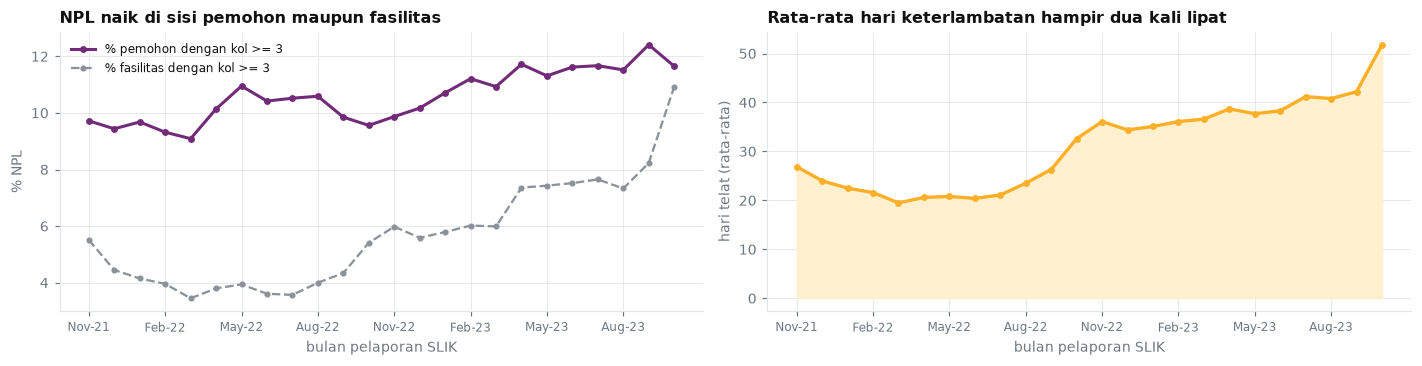

Nov-21 -> Oct-23  (24 bulan)
  NPL pemohon   : 9.72% -> 11.65%
  NPL fasilitas : 5.51% -> 10.92%
  Rata-rata DPD : 26.9 hari -> 51.8 hari (1.9x)


In [10]:
t = trend.copy()
x = range(len(t))
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))

axes[0].plot(x, t["customer_npl_pct"], color=PURPLE, lw=2, marker="o", ms=3.5,
             label="% pemohon dengan kol >= 3")
axes[0].plot(x, t["facility_npl_pct"], color=SLATE, lw=1.5, ls="--", marker="o", ms=3,
             label="% fasilitas dengan kol >= 3")
axes[0].set_title("NPL naik di sisi pemohon maupun fasilitas")
axes[0].set_ylabel("% NPL")

axes[1].fill_between(x, t["avg_dpd_days"], color=AMBER_SOFT)
axes[1].plot(x, t["avg_dpd_days"], color=AMBER, lw=2.2, marker="o", ms=3.5)
axes[1].set_title("Rata-rata hari keterlambatan hampir dua kali lipat")
axes[1].set_ylabel("hari telat (rata-rata)")

for ax in axes:
    ax.set_xticks(list(x)[::3]); ax.set_xticklabels(t["month_label"][::3], fontsize=8)
    ax.set_xlabel("bulan pelaporan SLIK")
axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

awal, akhir = t.iloc[0], t.iloc[-1]
print(f"{awal['month_label']} -> {akhir['month_label']}  ({len(t)} bulan)")
print(f"  NPL pemohon   : {awal['customer_npl_pct']:.2f}% -> {akhir['customer_npl_pct']:.2f}%")
print(f"  NPL fasilitas : {awal['facility_npl_pct']:.2f}% -> {akhir['facility_npl_pct']:.2f}%")
print(f"  Rata-rata DPD : {awal['avg_dpd_days']:.1f} hari -> {akhir['avg_dpd_days']:.1f} hari "
      f"({akhir['avg_dpd_days']/awal['avg_dpd_days']:.1f}x)")

**Insight #4 — kualitas memburuk, jadi pengetatan kriteria tepat waktu:**
- NPL level pemohon naik dari **9,7% (Nov-21) ke 11,7% (Okt-23)**, dan NPL level fasilitas dari
  5,5% ke 10,9% — kenaikan di sisi fasilitas lebih tajam, artinya pemohon yang bermasalah kini
  bermasalah di **lebih banyak** fasilitas sekaligus.
- Rata-rata hari keterlambatan naik dari **26,9 ke 51,8 hari (1,9×)**. Kenaikan DPD biasanya
  mendahului kenaikan kolektibilitas, jadi tekanannya belum selesai pada akhir jendela.
- **Caveat pemilihan sampel:** populasi ini adalah pemohon yang melamar pada November 2023, jadi
  tren di atas menggambarkan riwayat *kohort pelamar tersebut*, bukan portofolio bank secara
  umum. Yang absah disimpulkan: pemohon yang datang di November 2023 membawa jejak SLIK yang
  memburuk, sehingga kriteria penerimaan yang lebih ketat justru relevan sekarang.

## 7. Karakteristik Demografis

Gabungan `demographic1` (usia, industri, status kawin, gender) dan `demographic2` (domisili,
pekerjaan, pendidikan). Target di bagian ini adalah **`ever_npl_12m`** — bukan tautologis di sini
karena demografi tidak dipakai membentuk kolom tersebut, dan 82 kejadian jauh lebih stabil untuk
dipecah per kelompok daripada 20.

Setiap angka disertai **selang kepercayaan Wilson 95%** dan jumlah sampel. Tanpa itu, kelompok
berisi 12 orang akan terlihat sama meyakinkan dengan kelompok berisi 200 orang — kesalahan baca
yang paling sering terjadi pada analisis demografi.

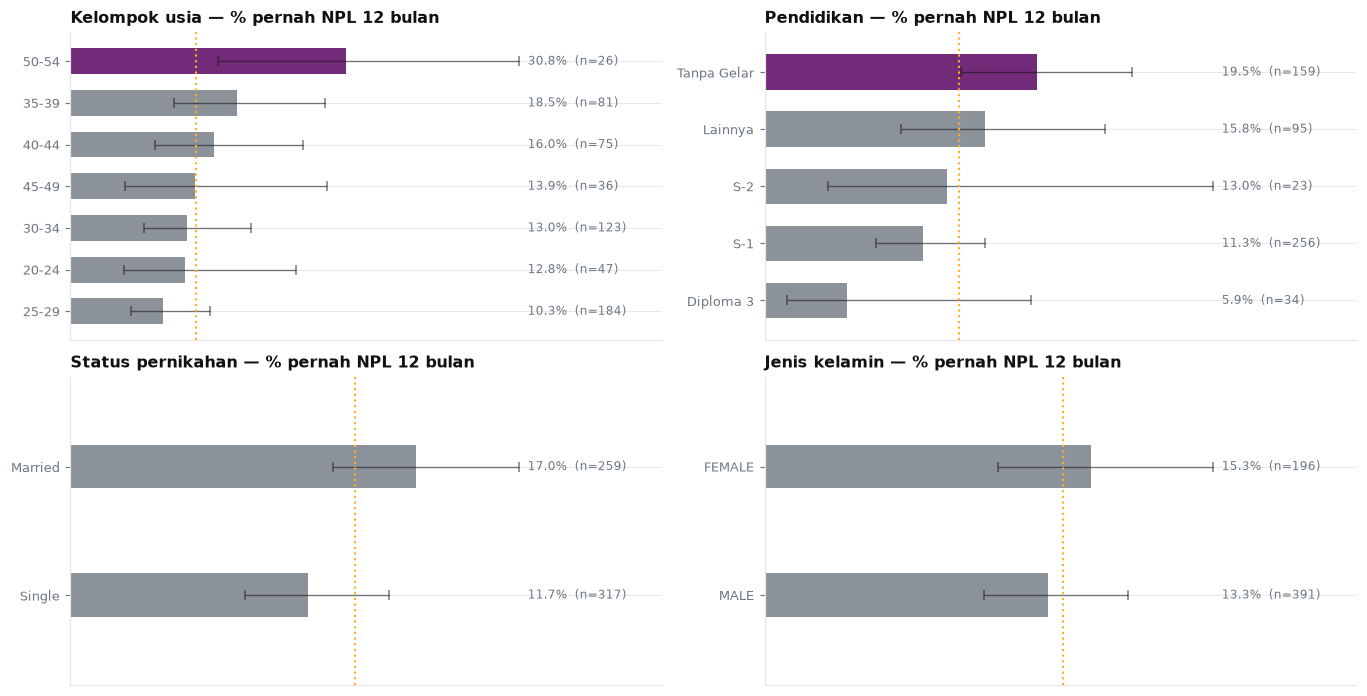

Garis putus-putus = rata-rata basis 14.0%.  Batang ungu = selang kepercayaan 95%-nya seluruhnya di atas rata-rata basis.


In [11]:
def wilson(k, n, z=1.96):
    if not n:
        return 0.0, 0.0
    p, d = k / n, 1 + z * z / n
    c = p + z * z / (2 * n)
    s = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return (c - s) / d, (c + s) / d

def rate_by(col, min_n=15, target="ever_npl_12m"):
    g = cust.groupby(col).agg(n=("NIK", "size"), k=(target, "sum"))
    g = g[g["n"] >= min_n].copy()
    g["rate"] = 100 * g["k"] / g["n"]
    g[["lo", "hi"]] = [[100 * v for v in wilson(k, n)] for k, n in zip(g["k"], g["n"])]
    return g.sort_values("rate", ascending=False)

basis = 100 * cust["ever_npl_12m"].mean()
fig, axes = plt.subplots(2, 2, figsize=(12.5, 6.4))
for ax, col, judul in [(axes[0, 0], "age_group", "Kelompok usia"),
                       (axes[0, 1], "pendidikan", "Pendidikan"),
                       (axes[1, 0], "marital_status", "Status pernikahan"),
                       (axes[1, 1], "gender", "Jenis kelamin")]:
    g = rate_by(col).iloc[::-1]
    # Sorot hanya kelompok yang selang kepercayaannya TIDAK memotong rata-rata basis.
    warna = [PURPLE if lo > basis else SLATE for lo in g["lo"]]
    tinggi = .62 if len(g) > 3 else .34     # jaga ketebalan batang tetap seragam antar panel
    ax.barh(g.index.astype(str), g["rate"], color=warna, height=tinggi)
    ax.errorbar(g["rate"], range(len(g)), xerr=[g["rate"] - g["lo"], g["hi"] - g["rate"]],
                fmt="none", ecolor=INK, elinewidth=.9, capsize=3, alpha=.55)
    for i, (r, n) in enumerate(zip(g["rate"], g["n"])):
        ax.text(g["hi"].max() * 1.02, i, f"{r:.1f}%  (n={n})", va="center", fontsize=8, color=MUTED)
    ax.axvline(basis, color=AMBER, ls=":", lw=1.4)
    ax.set_title(f"{judul} — % pernah NPL 12 bulan")
    ax.set_xlim(0, g["hi"].max() * 1.32); ax.set_xticks([])
    ax.set_ylim(-.7, len(g) - .3)
    ax.tick_params(axis="y", labelsize=8.5)
plt.tight_layout(); plt.show()
print(f"Garis putus-putus = rata-rata basis {basis:.1f}%.  Batang ungu = selang kepercayaan "
      f"95%-nya seluruhnya di atas rata-rata basis.")

In [12]:
print("=== Kelompok dengan selang kepercayaan 95% seluruhnya di atas rata-rata basis ===")
menonjol = []
for col, judul in [("age_group", "Kelompok usia"), ("pendidikan", "Pendidikan"),
                   ("marital_status", "Status pernikahan"), ("gender", "Jenis kelamin"),
                   ("pekerjaan", "Pekerjaan"), ("kab_kota", "Kab/Kota")]:
    g = rate_by(col, min_n=15)
    for kat, row in g[g["lo"] > basis].iterrows():
        menonjol.append({"dimensi": judul, "kategori": kat, "n": int(row["n"]),
                         "rate_pct": round(row["rate"], 1),
                         "CI95": f"{row['lo']:.1f}% - {row['hi']:.1f}%"})
print(pd.DataFrame(menonjol).to_string(index=False) if menonjol
      else "(tidak ada — seluruh selisih demografi masih di dalam rentang ketidakpastian)")

print("\n=== Bad rate per pekerjaan (n>=10, 8 teratas) ===")
pk = rate_by("pekerjaan", min_n=10).head(8).round(1)
pk.index = [s[:32] + ("..." if len(s) > 32 else "") for s in pk.index]
print(pk.rename_axis("pekerjaan").to_string())

=== Kelompok dengan selang kepercayaan 95% seluruhnya di atas rata-rata basis ===
      dimensi    kategori   n  rate_pct          CI95
Kelompok usia       50-54  26     30.80 16.5% - 50.0%
   Pendidikan Tanpa Gelar 159     19.50 14.1% - 26.3%

=== Bad rate per pekerjaan (n>=10, 8 teratas) ===
                                       n   k  rate    lo    hi
pekerjaan                                                     
Eksekutif                             15   3 20.00  7.00 45.20
Ibu Rumah Tangga                      11   2 18.20  5.10 47.70
Wiraswasta                            93  14 15.10  9.20 23.70
Lain-lain                            322  46 14.30 10.90 18.50
Pegawai Pemerintahan/Lembaga Neg...   18   2 11.10  3.10 32.80
Administrasi umum                     34   2  5.90  1.60 19.10
Pelajar/Mahasiswa                     24   1  4.20  0.70 20.20


**Insight #5 — demografi memberi arah, bukan keputusan:**
- Setelah memperhitungkan ketidakpastian, hanya **dua kelompok** yang selang kepercayaan 95%-nya
  seluruhnya berada di atas rata-rata basis (14,0%): **usia 50–54** (30,8%, CI 16,5–50,0%, n=26)
  dan pendidikan **Tanpa Gelar** (19,5%, CI 14,1–26,3%, n=159). Sisanya — termasuk seluruh
  perbedaan gender dan status pernikahan — **masih beririsan** dengan rata-rata basis.
- Kedua pengecualian itu pun perlu dibaca hati-hati: kelompok 50–54 hanya berisi 26 orang sehingga
  CI-nya selebar 33pp, dan batas bawah "Tanpa Gelar" (14,1%) hanya menyerempet rata-rata basis.
  Keduanya sinyal untuk **dipantau**, belum bukti untuk dijadikan aturan.
- Pada 587 pemohon, kelompok berisi 20–40 orang punya CI selebar 15–20pp — cukup lebar untuk
  menelan hampir semua selisih yang terlihat mencolok di grafik batang sederhana. Ini alasan
  setiap angka di sini ditampilkan bersama `n` dan CI-nya.
- Selain lemah secara statistik, aturan berbasis usia, gender, atau status pernikahan membawa
  **risiko diskriminasi** pada karakteristik yang dilindungi. Rekomendasi: pakai demografi untuk
  **memantau komposisi portofolio**, dan tangani kantong berisiko lewat **limit awal kecil +
  graduasi bertahap**, bukan penolakan.
- Sinyal SLIK (jejak keterlambatan, jumlah fasilitas) jauh lebih kuat dan lebih dapat
  dipertanggungjawabkan daripada atribut demografis mana pun di dataset ini.

## 8. Simulasi Kebijakan Whitelist

Bagian ini menggabungkan seluruh temuan menjadi usulan kriteria, lalu mengukur dampaknya pada dua
sisi yang selalu bertarung dalam kebijakan kredit: **berapa banyak pemohon yang dipertahankan**
versus **berapa banyak risiko yang tertahan**.

Setiap skenario dievaluasi terhadap tiga ukuran sekaligus supaya pembaca bisa melihat sendiri
mana angka yang informatif dan mana yang mekanis.

In [13]:
def simulasi(maks_kol_12m=2, maks_dpd_3m=0, wajib_others=True):
    m = pd.Series(True, index=cust.index)
    if wajib_others:
        m &= cust["whitelist_flag"] == "3.Customer Others"
    m &= cust["collection_status_allcondition_last_12months_max"].fillna(1) <= maks_kol_12m
    m &= cust["dpd_allcondition_last_3months_max"].fillna(0) <= maks_dpd_3m
    n = int(m.sum())
    return {"lolos": n, "pct_basis": round(100 * n / len(cust), 1),
            "npl_active_pct": round(100 * cust.loc[m, "npl_now_active"].mean(), 2),
            "npl_now_pct": round(100 * cust.loc[m, "npl_now"].mean(), 2),
            "npl_12m_pct": round(100 * cust.loc[m, "ever_npl_12m"].mean(), 2),
            "npl_aktif_lolos": int(cust.loc[m, "npl_now_active"].sum())}

scen = pd.DataFrame([
    {"skenario": "S0 - Semua aplikasi (tanpa filter)", **simulasi(99, 9999, False)},
    {"skenario": "S1 - Flag Others saja (kriteria saat ini)", **simulasi(99, 9999, True)},
    {"skenario": "S2 - Others + Kol 12 bln <= 2", **simulasi(2, 9999, True)},
    {"skenario": "S3 - Others + Kol 12 bln <= 2 + DPD 3 bln = 0", **simulasi(2, 0, True)},
    {"skenario": "S4 - Others + Kol 12 bln = 1 + DPD 3 bln = 0", **simulasi(1, 0, True)},
]).set_index("skenario")

cek = int((scen[["lolos", "pct_basis", "npl_active_pct", "npl_now_pct", "npl_12m_pct"]].values
           != ref_scen.set_index("skenario").loc[scen.index].values).sum())
print(f"Cross-check vs output/whitelist_scenarios.csv (BigQuery & Excel): {cek} sel berbeda "
      f"{'-> IDENTIK' if cek == 0 else '-> PERIKSA'}")
scen

Cross-check vs output/whitelist_scenarios.csv (BigQuery & Excel): 0 sel berbeda -> IDENTIK


,lolos,pct_basis,npl_active_pct,npl_now_pct,npl_12m_pct,npl_aktif_lolos
skenario,,,,,,
S0 - Semua aplikasi (tanpa filter),587,100.00,3.41,11.93,13.97,20
S1 - Flag Others saja (kriteria saat ini),510,86.90,1.57,1.57,3.92,8
S2 - Others + Kol 12 bln <= 2,490,83.50,0.00,0.00,0.00,0
S3 - Others + Kol 12 bln <= 2 + DPD 3 bln = 0,459,78.20,0.00,0.00,0.00,0
S4 - Others + Kol 12 bln = 1 + DPD 3 bln = 0,428,72.90,0.00,0.00,0.00,0


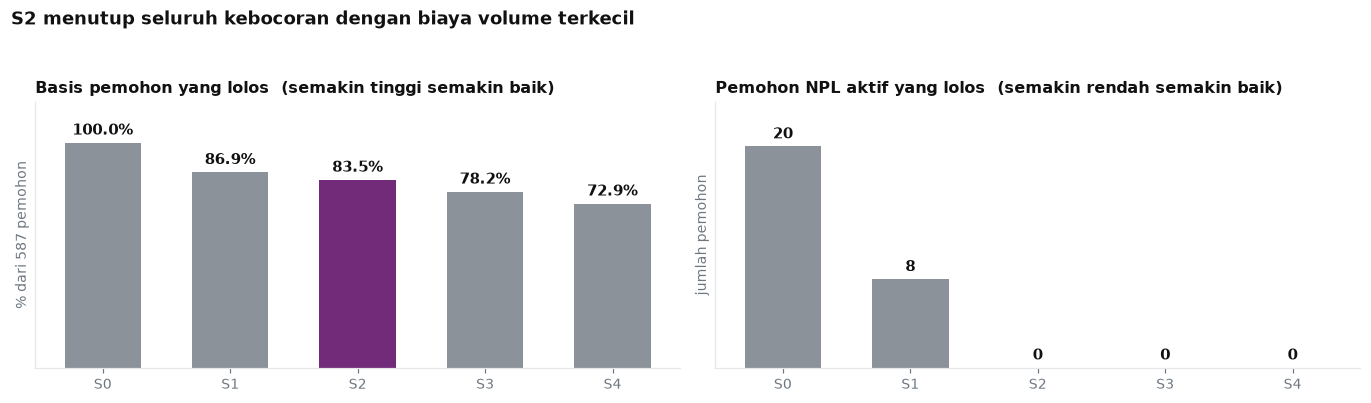

Keterangan skenario:
  S0 = Semua aplikasi (tanpa filter)
  S1 = Flag Others saja (kriteria saat ini)
  S2 = Others + Kol 12 bln <= 2
  S3 = Others + Kol 12 bln <= 2 + DPD 3 bln = 0
  S4 = Others + Kol 12 bln = 1 + DPD 3 bln = 0


In [14]:
lbl = [s.split(" - ")[0] for s in scen.index]
warna = [PURPLE if s.startswith("S2") else SLATE for s in scen.index]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.4))
b = axes[0].bar(lbl, scen["pct_basis"], color=warna, width=.6)
axes[0].bar_label(b, labels=[f"{v:.1f}%" for v in scen["pct_basis"]], padding=3,
                  fontsize=9.5, fontweight="bold")
axes[0].set_title("Basis pemohon yang lolos  (semakin tinggi semakin baik)")
axes[0].set_ylim(0, 118); axes[0].set_yticks([]); axes[0].set_ylabel("% dari 587 pemohon")

b = axes[1].bar(lbl, scen["npl_aktif_lolos"], color=warna, width=.6)
axes[1].bar_label(b, labels=[f"{int(v)}" for v in scen["npl_aktif_lolos"]], padding=3,
                  fontsize=9.5, fontweight="bold")
axes[1].set_title("Pemohon NPL aktif yang lolos  (semakin rendah semakin baik)")
axes[1].set_ylim(0, 24); axes[1].set_yticks([]); axes[1].set_ylabel("jumlah pemohon")
for ax in axes:
    ax.grid(axis="x", visible=False)
fig.suptitle("S2 menutup seluruh kebocoran dengan biaya volume terkecil",
             fontsize=11.5, fontweight="bold", x=.008, ha="left", y=1.06)
plt.tight_layout(); plt.show()

print("Keterangan skenario:")
for s in scen.index:
    kode, syarat = s.split(" - ", 1)
    print(f"  {kode} = {syarat}")

In [15]:
# Siapa saja 20 pemohon yang digugurkan S2 dibanding kriteria saat ini (S1)?
oth = cust["whitelist_flag"] == "3.Customer Others"
k12 = cust["collection_status_allcondition_last_12months_max"].fillna(1)
ditolak = cust[oth & (k12 > 2)]

masih_npl = ditolak[ditolak["npl_now_active"] == 1]
pulih     = ditolak[ditolak["npl_now_active"] == 0]
print(f"S1 -> S2 menggugurkan {len(ditolak)} pemohon:")
print(f"  {len(masih_npl):2d} memang masih NPL di fasilitas aktif  -> penolakan tepat")
print(f"  {len(pulih):2d} fasilitas aktifnya kini lancar/DPK       -> kandidat rehabilitasi")
print("\nKolektibilitas fasilitas aktif kelompok yang sudah pulih:")
print(pulih["kol_now_active_max"].value_counts().sort_index().rename("pemohon").to_frame()
      .rename_axis("kol fasilitas aktif").to_string())

# Apakah 0% NPL aktif pada S2 informatif atau mekanis? Cek langsung.
mekanis = int((cust["npl_now_active"] == 1).sum()) - int(((cust["npl_now_active"] == 1) & (k12 > 2)).sum())
print(f"\nPemohon NPL aktif yang kol 12 bulannya <= 2: {mekanis} dari "
      f"{int(cust['npl_now_active'].sum())}")
print("-> nol; artinya angka 0% pada S2 SEBAGIAN bersifat mekanis, bukan bukti prediktif.")

S1 -> S2 menggugurkan 20 pemohon:
   8 memang masih NPL di fasilitas aktif  -> penolakan tepat
  12 fasilitas aktifnya kini lancar/DPK       -> kandidat rehabilitasi

Kolektibilitas fasilitas aktif kelompok yang sudah pulih:
                     pemohon
kol fasilitas aktif         
1.00                      11
2.00                       1

Pemohon NPL aktif yang kol 12 bulannya <= 2: 0 dari 20
-> nol; artinya angka 0% pada S2 SEBAGIAN bersifat mekanis, bukan bukti prediktif.


**Insight #6 — rekomendasi: jalankan S2, dengan satu catatan yang harus disampaikan apa adanya.**

Kriteria usulan: `whitelist_flag = '3.Customer Others'` **DAN** kolektibilitas maksimum
12 bulan terakhir **≤ 2**.

**Yang dibuktikan angka:**
- Kriteria yang berjalan sekarang (S1) **meloloskan 8 pemohon yang masih NPL pada fasilitas
  aktif**. Kebocoran ini nyata dan bukan artefak definisi: `whitelist_flag` dibentuk dari
  write-off & restrukturisasi, sama sekali tidak menyentuh kolektibilitas.
- Satu syarat tambahan menutup seluruh delapan kebocoran itu dengan biaya **20 pemohon
  (basis 86,9% → 83,5%, turun 3,4pp)**. Syaratnya pun tersedia di tabel agregat yang sama,
  jadi tidak perlu data baru.
- **S3 dan S4 tidak menambah proteksi sedikit pun** pada ketiga ukuran risiko, tetapi memotong
  basis 5,3pp dan 10,6pp lagi. Pengetatan tanpa imbal hasil.

**Yang TIDAK dibuktikan angka (batas kejujuran analisis ini):**
- Angka 0% NPL pada S2 **sebagian bersifat mekanis**. Seluruh 20 pemohon NPL-aktif ternyata juga
  berkolektibilitas ≥ 3 dalam 12 bulan, sehingga filternya otomatis menyapu mereka. Yang absah
  disimpulkan adalah **kebocoran S1 tertutup**, bukan bahwa NPL S2 ke depan akan nol.
- Validasi sesungguhnya menuntut **vintage analysis** atas performa pinjaman setelah November 2023,
  yang tidak tersedia pada dataset statis ini.

**Usulan pelengkap — jalur rehabilitasi.** Dari 20 pemohon yang digugurkan S2, hanya 8 yang masih
NPL; **12 lainnya fasilitas aktifnya sudah kembali lancar** (11 kol 1, 1 kol 2). Menolak mereka
permanen berarti membuang pemohon yang sudah pulih. Sediakan jalur peninjauan: kol fasilitas aktif
= 1 selama ≥ 6 bulan berturut-turut → boleh masuk whitelist dengan limit awal terbatas. Pola yang
sama berlaku bagi 9 dari 16 pemohon restrukturisasi yang sudah kol 1 (Insight #1).

## 9. Kesimpulan & Rekomendasi

| # | Temuan | Angka kunci | Rekomendasi bisnis |
|---|---|---|---|
| 1 | Kriteria whitelist saat ini masih meloloskan pemohon yang sedang NPL | 8 pemohon "Others" NPL di fasilitas aktif; 13 pernah kol 3–5 dalam 6 bulan | Tambahkan syarat kol maks 12 bulan ≤ 2 (**S2**); basis turun 3,4pp saja |
| 2 | Pengetatan lebih jauh tidak berbayar | S3 & S4 memotong 5,3–10,6pp basis tanpa menurunkan risiko | Berhenti di S2; jangan tambah syarat DPD 3 bulan = 0 |
| 3 | Jumlah fasilitas & jejak keterlambatan adalah pemisah risiko terkuat | Gini 0,91 (`flags_active_dpd10plus_count`) dan 0,28 (`flags_allcondition_count`) | Jadikan inti scorecard / knock-out rule dan early-warning credit-shopping |
| 4 | Eksposur besar justru lebih aman | bad rate desil 1 = 20,3% vs desil 10 = 8,5%; Gini 0,12 arah terbalik | Pakai `slik_exposure` untuk *limit sizing*/DBR, bukan cut-off risiko |
| 5 | Seperempat basis adalah *thin file* | 154 pemohon (26,2%) tanpa eksposur aktif | Perlakukan sebagai kelompok tersendiri: limit awal kecil + graduasi |
| 6 | Kualitas portofolio memburuk selama jendela pengamatan | NPL 9,7% → 11,7%; DPD 26,9 → 51,8 hari | Perkuat monitoring bulanan; kriteria ketat relevan sekarang |
| 7 | Sebagian pemohon bermasalah sudah pulih | 12 dari 20 yang digugurkan S2 kini kol 1–2; 9 dari 16 restru sudah kol 1 | Buat jalur rehabilitasi berbasis kol aktif ≥ 6 bulan, bukan reject permanen |
| 8 | Demografi lemah dan berisiko diskriminatif | hanya 2 kelompok yang CI 95%-nya di atas basis | Pakai untuk monitoring komposisi, bukan aturan penolakan |
| 9 | Tidak ada kartu kredit aktif di portofolio | 0 fasilitas `X-30` dengan `kondisi = '0'` | Komponen CC pada kedua metrik = 0; formula siap bila produk CC masuk |

**Batasan yang perlu diketahui pembaca.** Dataset adalah snapshot statis 587 pemohon tanpa
*outcome window* ke depan, sehingga seluruh evaluasi bersifat *point-in-time*. Rekomendasi S2
menutup kebocoran yang terukur hari ini; pembuktian daya prediksinya menunggu vintage analysis
setelah November 2023. Ukuran sampel juga membatasi analisis per sel demografi.

**Konsistensi angka lintas deliverable.** Dua sel *cross-check* di bagian 5 dan 8 memverifikasi
bahwa Information Value/Gini/AUC dan seluruh baris simulasi kebijakan di notebook ini **identik**
dengan yang dihasilkan pipeline SQL BigQuery (`sql/03_analysis_views.sql`) dan yang tercetak di
dashboard Excel/Looker Studio. Jadi angka yang sama bisa dikutip dari deliverable mana pun tanpa
perlu rekonsiliasi.

*Seluruh angka dapat direproduksi end-to-end: CSV mentah → SQL BigQuery (tervalidasi silang
DuckDB & pandas) → notebook ini.*